In [1]:
import os
from math import sqrt
import pickle
import warnings
import time

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import xarray as xr
from sklearn.mixture import GaussianMixture
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap

from utils import read_xarray

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Check if CUDA is available and set the device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Load Data

In [3]:
data_type = "CESM"
data_num = "001"

# Read input data
rdir = os.getcwd()
dir_name = rdir + "/data"
chl, mld, sss, sst, u10, xco2, icefrac, patm, pco2 = read_xarray(dir_name, data_type, data_num)

chl = chl.Chl.data[:420, ::-1]
socat_mask = pco2.pCO2_socat.data[:420, ::-1] > 0.5
pco2 = pco2.pCO2.data[:420, ::-1]

# Prepare land mask and SOCAT mask
land_mask = xr.open_dataset(dir_name + "/land.nc").mask.data[::-1]
land_mask = (~np.isnan(land_mask))[np.newaxis, :, :]
land_mask = np.broadcast_to(land_mask, (420, 180, 360))
land_mask = land_mask & (pco2 > 0.5) & (chl > 0)

socat_mask = land_mask & socat_mask

In [4]:
# Load province data
with open('province_maps/all_provinces_CESM001.pkl', 'rb') as f:
    all_provinces = pickle.load(f)
land_mask2 = xr.open_dataset(dir_name + "/land.nc").mask.data[::-1]

In [5]:
province6 = np.sum(all_provinces == 5, axis=0)
province6 = province6.astype(float)
province6[np.isnan(land_mask2)] = np.nan

# Figure A1

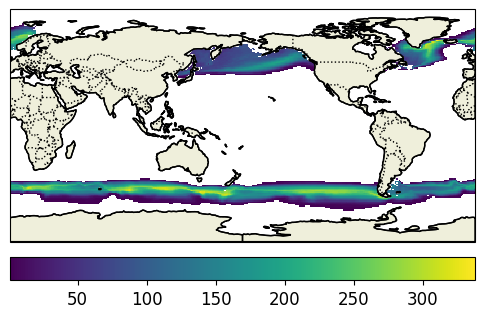

In [6]:
# Define latitude and longitude for plotting
lat = np.linspace(89.5, -89.5, province6.shape[0])
lon = np.linspace(0.5, 359.5, province6.shape[1])

lon, lat = np.meshgrid(lon, lat)

# Convert zeros to NaN so they will not be plotted
masked = province6.astype(float).copy()
masked[masked == 0] = np.nan

# Set NaN (bad) values to be fully transparent
cmap = plt.cm.viridis.copy()
cmap.set_bad(color=(0, 0, 0, 0))  # RGBA = transparent

# Plot the province data
fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()

c = ax.pcolormesh(lon, lat, masked, transform=ccrs.PlateCarree(), cmap=cmap)

# # Add red rectangle
# rect = patches.Rectangle((125, 35), 120, 30, linewidth=2, edgecolor='red', facecolor='none',
#                          transform=ccrs.PlateCarree())
# ax.add_patch(rect)

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')

# Colorbar
cbar = plt.colorbar(c, orientation='horizontal', pad=0.05)
cbar.ax.tick_params(labelsize=12)

# Save figure
plt.savefig('fig/province6_denominator.pdf', format='pdf')

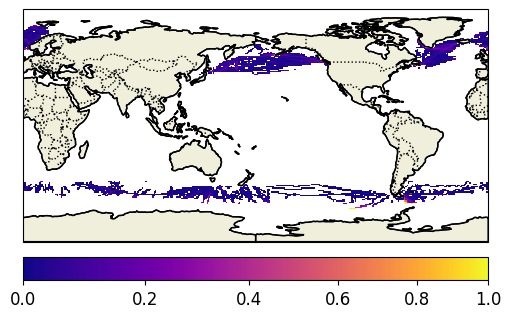

In [7]:
# Plot the observed province data
obv_pro6 = np.sum((all_provinces == 5) & socat_mask, axis=0)
obv_pro6 = obv_pro6.astype(float)
obv_pro6[np.isnan(land_mask2)] = np.nan

obv_pro6_den = obv_pro6 / province6

# Convert zeros to NaN so they will not be shown
obv_pro6_den = obv_pro6_den.astype(float)
obv_pro6_den[obv_pro6_den < 1/420] = np.nan

lat = np.linspace(89.5, -89.5, obv_pro6_den.shape[0])
lon = np.linspace(0.5, 359.5, obv_pro6_den.shape[1])

lon, lat = np.meshgrid(lon, lat)

fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()

log_obv_pro6_den = np.log1p(obv_pro6_den)

# Define a custom normalization for the color scale
class LogNorm(mcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, clip=False):
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        return np.ma.masked_array(np.log1p(value) / np.log1p(self.vmax), mask=np.ma.getmask(value))

norm = LogNorm(vmin=0, vmax=1)

# Copy plasma colormap and set NaN values to transparent
cmap = plt.cm.plasma.copy()
cmap.set_bad(color=(0, 0, 0, 0))  # transparent for NaN

# Plot pcolormesh
c = ax.pcolormesh(
    lon, lat, obv_pro6_den,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm
)

# rect = patches.Rectangle((125, 35), 120, 30, linewidth=2, edgecolor='red', facecolor='none',
#                          transform=ccrs.PlateCarree())
# ax.add_patch(rect)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')

cbar = plt.colorbar(c, orientation='horizontal', pad=0.05)
cbar.ax.tick_params(labelsize=12)

plt.savefig('fig/province6_percentage.pdf', format='pdf')

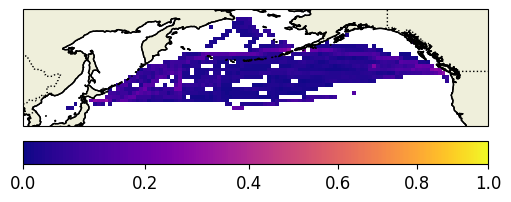

In [8]:
# Plot the observed province data for the North Pacific region
lat = np.linspace(89.5, -89.5, obv_pro6_den.shape[0])
lon = np.linspace(0.5, 359.5, obv_pro6_den.shape[1])

lon, lat = np.meshgrid(lon, lat)

fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

ax.set_extent([125, 245, 35, 65], crs=ccrs.PlateCarree())

c = ax.pcolormesh(
    lon, lat, obv_pro6_den,
    transform=ccrs.PlateCarree(),
    cmap='plasma',   # purple → yellow → red
    norm=norm
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')

cbar = plt.colorbar(c, orientation='horizontal', pad=0.05)
cbar.ax.tick_params(labelsize=12)

plt.savefig('fig/province6_percentage_north_pacific.pdf', format='pdf')

In [9]:
# Function to format y-axis labels
def log_format(value, tick_number):
    return f'{int(value):,}'

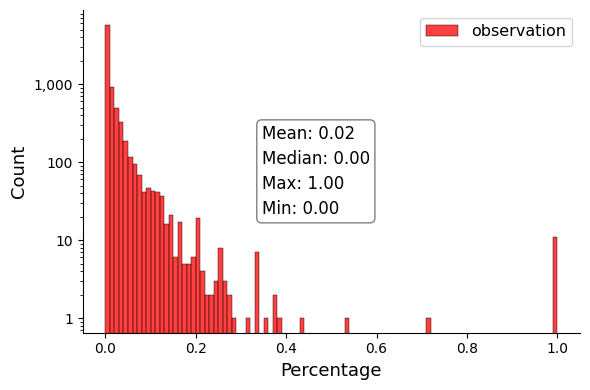

In [10]:
# Calculate statistics for the observed province data
# Plot the observed province data
obv_pro6 = np.sum((all_provinces == 5) & socat_mask, axis=0)
obv_pro6 = obv_pro6.astype(float)
obv_pro6[np.isnan(land_mask2)] = np.nan

obv_pro6_den = obv_pro6 / province6

# Convert zeros to NaN so they will not be shown
obv_pro6_den = obv_pro6_den.astype(float)
obv_pro6_den_pure = obv_pro6_den[~np.isnan(obv_pro6_den)]
mean_value = np.mean(obv_pro6_den_pure)
median_value = np.median(obv_pro6_den_pure)
max_value = np.max(obv_pro6_den_pure)
min_value = np.min(obv_pro6_den_pure)

# ============================
# First figure: all values
# ============================
fig = plt.figure(figsize=(6, 4))
deep_red = (0.3, 0, 0)

sns.histplot(obv_pro6_den_pure, bins=100, color='red', label='observation')
plt.xlabel('Percentage', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.yscale('log')
plt.legend(prop={'size': 11.5})
plt.gca().yaxis.set_major_formatter(FuncFormatter(log_format))

# Statistics text box
textstr = '\n'.join((
    f'Mean: {mean_value:.2f}',
    f'Median: {median_value:.2f}',
    f'Max: {max_value:.2f}',
    f'Min: {min_value:.2f}'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.text(0.36, 0.5, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='left',
         bbox=props, linespacing=1.5)

# Hide unnecessary spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig/province6_hist.pdf', format='pdf')
plt.show()

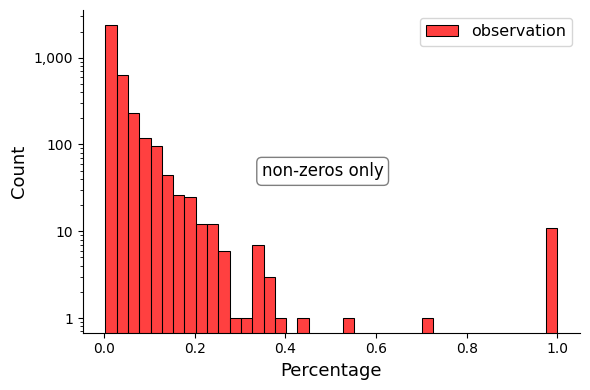

In [11]:
# Calculate statistics for the observed province data without zero
obv_pro6_den_nonzero = obv_pro6_den_pure[obv_pro6_den_pure != 0]

# ============================
# Second figure: non-zero only
# ============================
fig = plt.figure(figsize=(6, 4))

sns.histplot(obv_pro6_den_nonzero, bins=40, color='red', label='observation')
plt.xlabel('Percentage', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.yscale('log')
plt.legend(prop={'size': 11.5})
plt.gca().yaxis.set_major_formatter(FuncFormatter(log_format))

# Text box
textstr = "non-zeros only"
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.text(0.36, 0.5, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='left',
         bbox=props, linespacing=1.5)

# Hide unnecessary spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig/province6_hist_nonzero.pdf', format='pdf')
plt.show()

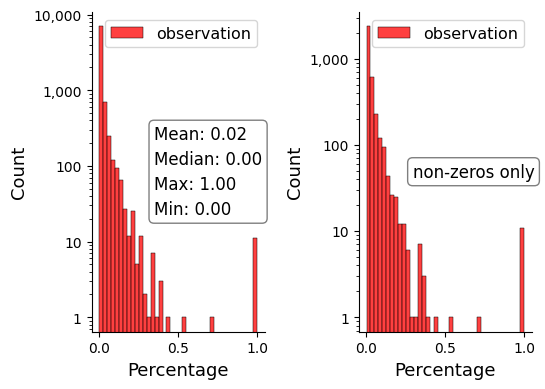

In [12]:
# Plot 2 histograms together
fig, axs = plt.subplots(1, 2, figsize=(6, 4))

deep_red = (0.3, 0, 0)

sns.histplot(obv_pro6_den_pure, bins=40, color='red', label='observation', ax=axs[0])
axs[0].set_xlabel('Percentage', fontsize=13)
axs[0].set_ylabel('Count', fontsize=13)
axs[0].set_yscale('log')
axs[0].legend(prop={'size': 11.5})
axs[0].get_yaxis().set_major_formatter(FuncFormatter(log_format))

textstr = '\n'.join((
    f'Mean: {mean_value:.2f}',
    f'Median: {median_value:.2f}',
    f'Max: {max_value:.2f}',
    f'Min: {min_value:.2f}'
))

props = dict(boxstyle='round', facecolor='white', alpha=0.5)
axs[0].text(0.36, 0.5, textstr, transform=axs[0].transAxes, fontsize=12,
            verticalalignment='center', horizontalalignment='left', bbox=props, linespacing=1.5)

# Hide unnecessary plot spines
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['left'].set_visible(True)
axs[0].spines['bottom'].set_visible(True)

# the second plot
sns.histplot(obv_pro6_den_nonzero, bins=40, color='red', label='observation', ax=axs[1])
axs[1].set_xlabel('Percentage', fontsize=13)
axs[1].set_ylabel('Count', fontsize=13)
axs[1].set_yscale('log')
axs[1].legend(prop={'size': 11.5})
axs[1].get_yaxis().set_major_formatter(FuncFormatter(log_format))

textstr = "non-zeros only"
axs[1].text(1.85, 0.5, textstr, transform=axs[0].transAxes, fontsize=12,
            verticalalignment='center', horizontalalignment='left', bbox=props, linespacing=1.5)

# Hide unnecessary plot spines
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['left'].set_visible(True)
axs[1].spines['bottom'].set_visible(True)

plt.tight_layout()
plt.savefig('fig/province6_hist_com.pdf', format='pdf')

# Figure 3

In [13]:
# Read CESM 002 data
chl_CESM002, mld_CESM002, sss_CESM002, sst_CESM002, u10_CESM002, xco2_CESM002, icefrac_CESM002, patm_CESM002, \
pco2_CESM002 = read_xarray(dir_name, 'CESM', '002')
pco2_CESM002 = pco2_CESM002.pCO2.data[:420, ::-1]
with open('province_maps/all_provinces_CESM002.pkl', 'rb') as f:
    all_provinces_CESM002 = pickle.load(f)

In [14]:
province = 5
month_name = ['Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan']

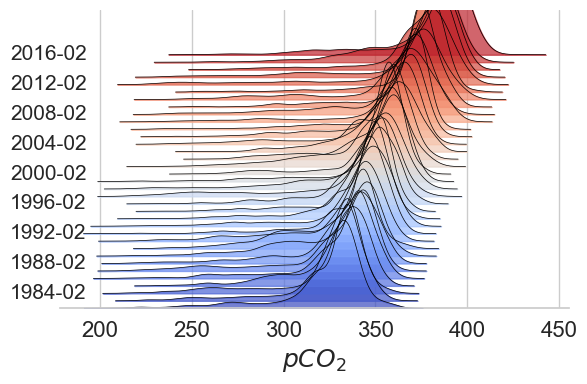

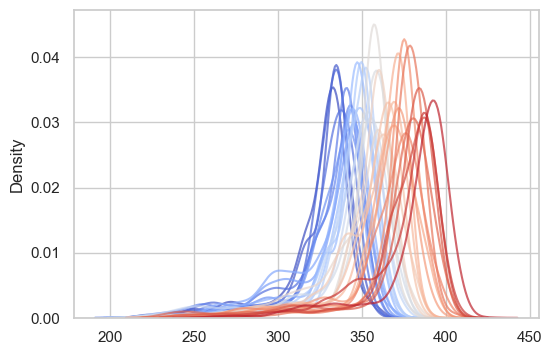

In [15]:
# Loop through each month to create density plots
for month in range(12):
    sns.set(style="whitegrid")  # Set Seaborn plot style to whitegrid

    fig, ax = plt.subplots(figsize=(6, 4))  # Create a new figure and axis

    cmap = plt.get_cmap('coolwarm')  # Get the 'coolwarm' colormap
    num_months = 35  # Number of months to plot
    colors = [cmap(i / num_months) for i in range(num_months)]  # Generate a list of colors
    plt.subplots(figsize=(6, 4))  # Create a new subplot

    shift = 0.3  # Vertical shift for KDE plots
    text_x_position = 300  # Initial x position for text annotations

    # Loop through each month's data
    for month_idx in range(num_months):
        # Get pCO2 data for the current month and province
        data = pco2_CESM002[month + 12 * month_idx][
            land_mask[month + 12 * month_idx] & (all_provinces_CESM002[month + 12 * month_idx] == province)
        ]

        if data.size > 0:  # If there is data for the current month
            # Plot KDE for the current month's data
            kde = sns.kdeplot(data, fill=False, color=colors[month_idx], alpha=0.7, linewidth=1.5)
            kde_data = kde.get_lines()[-1].get_data()  # Get KDE line data
            kde_data_x = kde_data[0]  # X values of KDE
            kde_data_y = None  # Y values of KDE (to be determined below)

            # Adjust y values based on the current month
            if month in [3, 5, 6]:
                kde_data_y = 90 * kde_data[1] + month_idx * shift
            elif month in [4, 8, 7]:
                kde_data_y = 50 * kde_data[1] + month_idx * shift
            elif month == 10:
                kde_data_y = 20 * kde_data[1] + month_idx * shift
            elif month == 9:
                kde_data_y = 15 * kde_data[1] + month_idx * shift
            elif month == 11:
                kde_data_y = 80 * kde_data[1] + month_idx * shift
            else:
                kde_data_y = 100 * kde_data[1] + month_idx * shift

            # Fill the area under the KDE curve
            ax.fill_between(kde_data_x, kde_data_y, month_idx * shift, color=colors[month_idx], alpha=0.7)
            ax.plot(kde_data_x, kde_data_y, color='black', linewidth=0.5)  # Plot the KDE line

            year = 1982 + month_idx  # Calculate the year for the current month

            # Adjust text position if necessary
            if kde_data_x.min() - 40 < text_x_position:
                text_x_position = kde_data_x.min() - 40

    # Annotate the plot with year labels
    if month < 11:
        for year in range(1984, 2020, 4):
            ax.text(text_x_position, (year - 1982) * shift, f'{year}-{(month + 2):02d}', verticalalignment='center',
                    fontsize=15)
    else:
        for year in range(1985, 2021, 4):
            ax.text(text_x_position, (year - 1982) * shift, f'{year}-{1:02d}', verticalalignment='center',
                    fontsize=15)

    ax.set_ylim(0, (num_months + 5) * shift)  # Set y-axis limits
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xlabel(r'$pCO_2$', fontsize=18)  # Set x-axis label
    ax.tick_params(axis='x', labelsize=16)

    # Hide unnecessary plot spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    fig.tight_layout()  # Adjust the layout

    # Save the figure to a file
    fig.savefig(f'fig/month_density/province6_{month_name[month]}_density.pdf', format='pdf')

    if month == 0:
        plt.show()

    plt.close('all')  # Close the figure to free up memory

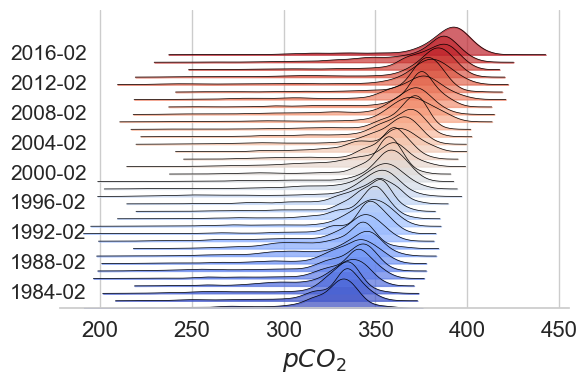

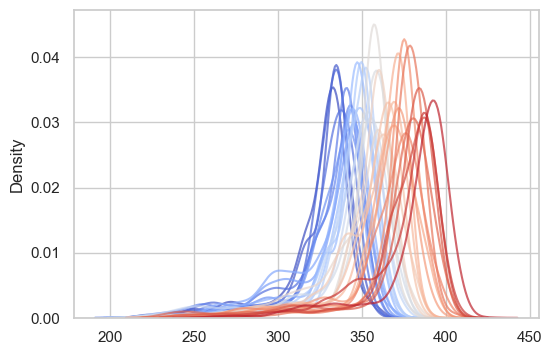

In [16]:
# Loop through each month to create density plots
for month in range(12):
    sns.set(style="whitegrid")  # Set Seaborn plot style to whitegrid

    fig, ax = plt.subplots(figsize=(6, 4))  # Create a new figure and axis

    cmap = plt.get_cmap('coolwarm')  # Get the 'coolwarm' colormap
    num_months = 35  # Number of months to plot
    colors = [cmap(i / num_months) for i in range(num_months)]  # Generate a list of colors
    plt.subplots(figsize=(6, 4))  # Keep this line if you want to preserve original behavior

    shift = 0.3  # Vertical shift for KDE plots
    text_x_position = 300  # Initial x position for text annotations

    # ============================================================
    # 1) First pass: find the maximum KDE density for this month
    # ============================================================
    dens_max = 0.0  # Track maximum KDE value over all years for this month

    for month_idx in range(num_months):
        data = pco2_CESM002[month + 12 * month_idx][
            land_mask[month + 12 * month_idx] & (all_provinces_CESM002[month + 12 * month_idx] == province)
        ]

        if data.size > 0:
            kde = sns.kdeplot(data, fill=False, color=colors[month_idx], alpha=0.7, linewidth=1.5)
            kde_line = kde.get_lines()[-1]
            kde_x, kde_y = kde_line.get_data()

            # Update maximum density
            if kde_y.size > 0:
                dens_max = max(dens_max, kde_y.max())

            # Remove this temporary line so the first pass does not show anything
            kde_line.remove()

    # If there is no data at all, avoid division by zero
    if dens_max > 0:
        target_peak = 1.5  # Desired max height above baseline for the tallest ridge
        scale = target_peak / dens_max
    else:
        scale = 1.0  # Fallback (no data case)

    # ============================================================
    # 2) Second pass: actually draw the ridgeline plot with scaling
    # ============================================================
    text_x_position = 300  # Reset text position for this month

    for month_idx in range(num_months):
        # Get pCO2 data for the current month and province
        data = pco2_CESM002[month + 12 * month_idx][
            land_mask[month + 12 * month_idx] & (all_provinces_CESM002[month + 12 * month_idx] == province)
        ]

        if data.size > 0:  # If there is data for the current month
            # Plot KDE for the current month's data
            kde = sns.kdeplot(data, fill=False, color=colors[month_idx], alpha=0.7, linewidth=1.5)
            kde_data = kde.get_lines()[-1].get_data()  # Get KDE line data
            kde_data_x = kde_data[0]  # X values of KDE
            kde_data_y_raw = kde_data[1]  # Raw KDE Y values
            kde_data_y = scale * kde_data_y_raw + month_idx * shift  # Scaled and shifted Y

            # Fill the area under the KDE curve
            ax.fill_between(kde_data_x, kde_data_y, month_idx * shift, color=colors[month_idx], alpha=0.7)
            ax.plot(kde_data_x, kde_data_y, color='black', linewidth=0.5)  # Plot the KDE line

            year = 1982 + month_idx  # Calculate the year for the current month

            # Adjust text position if necessary
            if kde_data_x.min() - 40 < text_x_position:
                text_x_position = kde_data_x.min() - 40

    # Annotate the plot with year labels
    if month < 11:
        for year in range(1984, 2020, 4):
            ax.text(text_x_position, (year - 1982) * shift,
                    f'{year}-{(month + 2):02d}',
                    verticalalignment='center', fontsize=15)
    else:
        for year in range(1985, 2021, 4):
            ax.text(text_x_position, (year - 1982) * shift,
                    f'{year}-{1:02d}',
                    verticalalignment='center', fontsize=15)

    # Keep your original ylim: with target_peak = 1.5 this will never clip
    ax.set_ylim(0, (num_months + 5) * shift)  # Set y-axis limits
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xlabel(r'$pCO_2$', fontsize=18)  # Set x-axis label
    ax.tick_params(axis='x', labelsize=16)

    # Hide unnecessary plot spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    fig.tight_layout()  # Adjust the layout

    # Save the figure to a file
    fig.savefig(f'fig/month_density/province6_{month_name[month]}_density.pdf', format='pdf')

    if month == 0:
        plt.show()

    plt.close('all')  # Close the figure to free up memory


# Figure

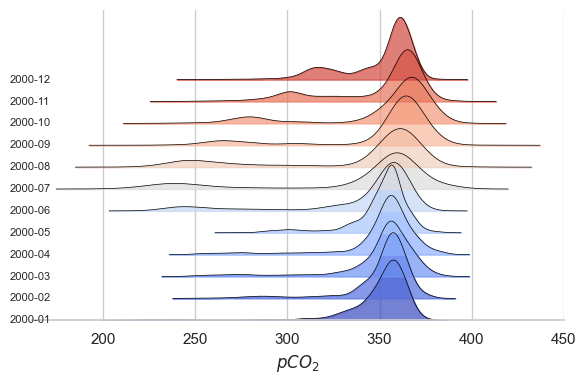

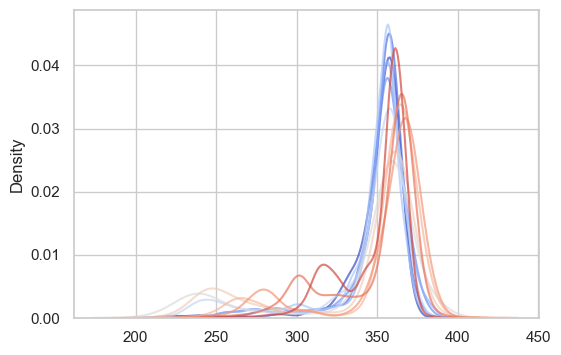

In [17]:
# Loop through each year to create density plots
for year in range(1982, 2017):
    sns.set(style="whitegrid")  # Set Seaborn plot style to whitegrid

    fig, ax = plt.subplots(figsize=(6, 4))  # Create a new figure and axis

    cmap = plt.get_cmap('coolwarm')  # Get the 'coolwarm' colormap
    num_months = 12  # Number of months in a year
    colors = [cmap(i / num_months) for i in range(num_months)]  # Generate a list of colors
    plt.subplots(figsize=(6, 4))  # Create a new subplot

    shift = 0.3  # Vertical shift for KDE plots
    text_x_position = 300  # Initial x position for text annotations
    max_y_value = 0  # Variable to store the maximum y value for setting y-axis limit

    # Loop through each month in the year
    if year == 1982:
        start_index = 1
    else:
        start_index = 0
    for month in range(start_index, 12):
        # Get pCO2 data for the current month and province
        data = pco2_CESM002[month - 1 + 12 * (year - 1982)][
            land_mask[month - 1 + 12 * (year - 1982)] & (all_provinces_CESM002[month - 1 + 12 * (year - 1982)] == province)
        ]

        if data.size > 0:  # If there is data for the current month
            # Plot KDE for the current month's data
            kde = sns.kdeplot(data, fill=False, color=colors[month], alpha=0.7, linewidth=1.5)
            kde_data = kde.get_lines()[-1].get_data()  # Get KDE line data
            kde_data_x = kde_data[0]  # X values of KDE
            kde_data_y = 20 * kde_data[1] + month * shift  # Adjust y values based on the current month

            # Fill the area under the KDE curve
            ax.fill_between(kde_data_x, kde_data_y, month * shift, color=colors[month], alpha=0.7)
            ax.plot(kde_data_x, kde_data_y, color='black', linewidth=0.5)  # Plot the KDE line

            # Adjust text position if necessary
            if kde_data_x.min() - 25 < text_x_position:
                text_x_position = kde_data_x.min() - 25

            # Update the maximum y value
            if kde_data_y.max() > max_y_value:
                max_y_value = kde_data_y.max()

    # Annotate the plot with month labels
    for month in range(start_index, 12):
        ax.text(text_x_position, month * shift, f'{year}-{(month + 1):02d}', verticalalignment='center', fontsize=8)

    ax.set_ylim(0, max_y_value + shift / 3)  # Set y-axis limits
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xlabel(r'$pCO_2$')  # Set x-axis label

    # Hide unnecessary plot spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    fig.tight_layout()  # Adjust the layout

    # Save the figure to a file
    fig.savefig(f'fig/year_density/province6_{year}_density.pdf', format='pdf')
    if year == 2000:
        plt.show()

    plt.close('all')  # Close the figure to free up memory

In [18]:
# Load raw predictions
with open('raw_y_hat.pkl', 'rb') as f:
    raw_y_hat = pickle.load(f)

# Kernelized Stein Discrepancy

In [19]:
def u_q(x_1, x_2, mu, var, pi, h):
    # Compute log probabilities and weights for GMM components
    log_probs = torch.log(pi) - 0.5 * torch.log(var) - (x_1 - mu) ** 2 / 2 / var
    log_weights1 = torch.log(x_1) - torch.log(var)
    log_weights2 = torch.log(mu) - torch.log(var)
    log_sum_weights1 = torch.logsumexp(log_probs + log_weights1, dim=1, keepdim=True)
    log_sum_weights2 = torch.logsumexp(log_probs + log_weights2, dim=1, keepdim=True)
    log_sum_probs = torch.logsumexp(log_probs, dim=1, keepdim=True)
    sq1 = torch.exp(log_sum_weights1 - log_sum_probs) - torch.exp(log_sum_weights2 - log_sum_probs)

    # Compute log probabilities and weights for the second input
    log_probs = (torch.log(pi) - 0.5 * torch.log(var)).unsqueeze(1) - (x_2 - mu.unsqueeze(1)) ** 2 / 2 / var.unsqueeze(1)
    log_weights1 = torch.log(x_2) - torch.log(var).unsqueeze(1)
    log_weights2 = (torch.log(mu) - torch.log(var)).unsqueeze(1)
    log_sum_weights1 = torch.logsumexp(log_probs + log_weights1, dim=0, keepdim=True)
    log_sum_weights2 = torch.logsumexp(log_probs + log_weights2, dim=0, keepdim=True)
    log_sum_probs = torch.logsumexp(log_probs, dim=0, keepdim=True)
    sq2 = torch.exp(log_sum_weights1 - log_sum_probs) - torch.exp(log_sum_weights2 - log_sum_probs)

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return sq1 * sq2
    else:
        return torch.exp(-(x_1 - x_2) ** 2 / 2 / (h ** 2)) * (
                    sq1 * sq2 - (sq1 - sq2) * (x_1 - x_2) / h ** 2 + 1 / h ** 2 - (x_1 - x_2) ** 2 / h ** 4)

In [20]:
def u_q_pairwise_sum_parallel(x_1: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor, pi: torch.Tensor, h: float, batch_size: int = 3000) -> torch.Tensor:
    n = x_1.shape[0]
    final_sum = 0.0

    # Compute pairwise sums in parallel batches
    for start_i in range(0, n, batch_size):
        end_i = min(start_i + batch_size, n)
        batch_sum = 0.0

        for start_j in range(0, n, batch_size):
            end_j = min(start_j + batch_size, n)
            block_i = x_1[start_i:end_i]
            block_j = x_1[start_j:end_j]

            results = u_q(block_i, block_j.reshape(1, -1), mu, sigma, pi, h)

            # Zero out diagonal elements for the same block
            if start_i == start_j:
                results.fill_diagonal_(0)

            batch_sum += torch.sum(results)

        final_sum += batch_sum

    return final_sum / sqrt(n)

# Main Algorithm

In [21]:
start = time.time()

In [22]:
# Initialize parameters for the second calibration
province = 5
batch_size = 3000
n_components = 5
is_standardize = True
lamb=0.01
max_step=201
tolerance=20
bandwidth=3
is_print = False
bounds = {k: (0, 700) for k in range(16)}

total_raw_SE = 0
total_opt_SE = 0
total_stan_SE = 0
total_raw_WDL = 0
total_opt_WDL = 0
total_stan_WDL = 0
total_n = 0
total_obv = 0

raw_SE_LOOs = np.zeros((12, 7))
opt_SE_LOOs = np.zeros((12, 7))
stan_SE_LOOs = np.zeros((12, 7))
raw_WDL_LOOs = np.zeros((12, 7))
opt_WDL_LOOs = np.zeros((12, 7))
stan_WDL_LOOs = np.zeros((12, 7))
number_LOOs = np.zeros((12, 7))

In [23]:
def calibration(pco2_ref, all_provinces_ref, month, province, batch_size, n_components, is_standardize=True, lamb=0.01,
                max_step=201, tolerance=20, bandwidth=3, draw_plot=False):
    months = list(range(month + 336, 420, 12))

    # Prepare training data based on the reference month and province
    train_y = pco2_ref[months][land_mask[months] & (all_provinces_ref[months] == province)]

    # Fit Gaussian Mixture Model (GMM)
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(train_y.reshape(-1, 1))

    # Extract GMM parameters
    means = torch.tensor(gmm.means_.flatten(), dtype=torch.float64, device=device)
    weights = torch.tensor(gmm.weights_.flatten(), dtype=torch.float64, device=device)
    covariances = torch.tensor(gmm.covariances_.flatten(), dtype=torch.float64, device=device)
    overall_mean = torch.dot(weights, means)
    overall_std = torch.sqrt(torch.dot(weights, means ** 2 + covariances) - overall_mean ** 2)

    # Prepare test data based on the reference month and province
    test_y = pco2[months][land_mask[months] & (all_provinces[months] == province)]
    y_test_hat = raw_y_hat[months][land_mask[months] & (all_provinces[months] == province)]

    # Calculate the number of data points in each month
    number_monthly = np.array(
        [np.sum(land_mask[months[i]] & (all_provinces[months[i]] == province)) for i in range(7)])

    # Normalize test predictions
    y_test_hat_tensor = torch.tensor(y_test_hat, dtype=torch.float64, device=device)
    if is_standardize:
        y_test_hat_tensor = torch.clip((y_test_hat_tensor - torch.mean(y_test_hat_tensor)) / torch.std(
            y_test_hat_tensor) * overall_std + overall_mean, bounds[province][0], bounds[province][1])
    else:
        y_test_hat_tensor = torch.clip(y_test_hat_tensor, bounds[province][0], bounds[province][1])
    y_test_hat_tensor = y_test_hat_tensor.clone().detach().requires_grad_(True)
    y_test_hat_tensor_numpy = y_test_hat_tensor.detach().cpu().clone().numpy()

    with torch.no_grad():
        h = bandwidth * torch.std(y_test_hat_tensor).item()

    # Pre-calculate GMM quantiles for dist_WDL
    q_vec = np.linspace(0, 1, 1000)
    gmm_quantiles = np.percentile(gmm.sample(10000)[0], q_vec * 100)

    # Early stopping
    early_stopping_patience = 0
    best_dist_wdl = float('inf')
    y_test_opt = None   # save optimal y during gradient descent

    best_result = {
        'iteration': -1,
        'se': None,
        'wdl': None,
        'ksd': None,
        'dist_wdl': float('inf')
    }

    n_test = len(y_test_hat_tensor)

    # Perform gradient descent with early stopping based on dist_WDL
    for step in range(max_step):
        KSD = 0

        # Compute pairwise discrepancies and gradients (this is where KSD is calculated through u_q)
        for start_i in range(0, n_test, batch_size):
            end_i = min(start_i + batch_size, n_test)
            for start_j in range(0, n_test, batch_size):
                end_j = min(start_j + batch_size, n_test)

                result = u_q(y_test_hat_tensor[start_i:end_i].unsqueeze(1),
                             y_test_hat_tensor[start_j:end_j].unsqueeze(0),
                             means, covariances, weights, h)
                if start_i == start_j:
                    result.fill_diagonal_(0)
                sum_result = torch.sum(result) / np.sqrt(n_test)
                sum_result.backward()
                with torch.no_grad():
                    KSD += sum_result

        # Clip gradients
        gradient = y_test_hat_tensor.grad
        gradient = torch.clip(gradient, -5 * torch.median(torch.abs(gradient)), 5 * torch.median(torch.abs(gradient)))

        with torch.no_grad():
            gradient /= torch.sqrt(torch.mean(gradient ** 2)) / torch.std(y_test_hat_tensor)

            # Adjust predictions to minimize discrepancy
            y_test_hat_tensor -= lamb * gradient

        y_test_hat_tensor.grad.zero_()  # Reset gradients

        # Calculate SE, WDL, KSD, and dist_WDL for this step
        y_test_hat_numpy = y_test_hat_tensor.detach().cpu().numpy()
        opt_SE = np.sum((y_test_hat_numpy - test_y) ** 2)
        opt_WDL = np.mean((np.quantile(test_y, q_vec) - np.quantile(y_test_hat_numpy, q_vec)) ** 2)
        opt_KSD = KSD.item()

        # Calculate dist_WDL (Wasserstein distance between y_test_hat and GMM quantiles)
        dist_WDL = np.sum((np.quantile(y_test_hat_numpy, q_vec) - gmm_quantiles) ** 2)

        # Early stopping logic
        if dist_WDL < best_dist_wdl:
            best_dist_wdl = dist_WDL
            y_test_opt = y_test_hat_numpy.copy()       # ← 关键：保存最佳 opt y
            best_result = {
                'iteration': step,
                'se': opt_SE,
                'wdl': opt_WDL,
                'ksd': opt_KSD,
                'dist_wdl': dist_WDL
            }
            early_stopping_patience = 0  # Reset patience if there's improvement
        else:
            early_stopping_patience += 1  # Increment patience if no improvement

        # Trigger early stopping if no improvement for 'tol' steps
        if early_stopping_patience >= tolerance:
            # print(f"Early stopping at step {step} for tolerance {tolerance} due to no improvement in dist_WDL.")
            break

    # Plot the results if requested
    if draw_plot:
        cmap = plt.get_cmap('coolwarm')
        colors = [cmap((3 - i) / 3) for i in range(4)]
        plt.subplots(figsize=(6, 4))

        if month == 0:
            start_index = 275
            end_index = 415
        elif month == 1:
            start_index = 270
            end_index = 415
        elif month == 2:
            start_index = 290
            end_index = 415
        elif month == 3:
            start_index = 315
            end_index = 410
        elif month == 4:
            start_index = 245
            end_index = 405
        elif month == 5:
            start_index = 230
            end_index = 420
        elif month == 6:
            start_index = 230
            end_index = 425
        elif month == 7:
            start_index = 255
            end_index = 420
        elif month == 8:
            start_index = 255
            end_index = 425
        elif month == 9:
            start_index = 290
            end_index = 420
        elif month == 10:
            start_index = 310
            end_index = 415
        elif month == 11:
            start_index = 280
            end_index = 410
        else:
            raise ValueError("Invalid month")
        breaks = torch.arange(start_index, end_index + 1, (end_index - start_index) / 20)
        plt.xlim(start_index - 15, end_index + 15)
        x = np.linspace(start_index - 15, end_index + 15, 3000)


        sns.histplot(test_y, bins=breaks, stat="density", color=colors[0], label=r"Actual $pCO_2$", alpha=0.5)
        sns.histplot(y_test_opt, bins=breaks, stat="density", color=colors[1], alpha=0.5,
                     label=r"Calibrated $pCO_2$")
        sns.histplot(y_test_hat, bins=breaks, stat="density", color=colors[3], alpha=0.5, label=r"Raw Predicted $pCO_2$")


        log_prob = gmm.score_samples(x.reshape(-1, 1))
        pdf = np.exp(log_prob)
        plt.plot(x, pdf, color='y', label='Knowledge PDF')

        plt.xlabel(r"$pCO_2$", fontsize=18)
        plt.xticks(fontsize=16)
        plt.ylabel('Density', fontsize=18)
        plt.yticks(fontsize=16)
        plt.tight_layout()
        plt.legend(prop={'size': 12.5})
        plt.savefig(f'fig/pco2_calibration/province{province + 1}_{month_name[month]}_calibration.pdf', format='pdf')
        if month == 6:
            plt.show()
        plt.close('all')

    # Calculate squared errors
    raw_SE = np.sum((y_test_hat - test_y) ** 2)
    opt_SE = np.sum((y_test_opt - test_y) ** 2)
    stan_SE = np.sum((y_test_hat_tensor_numpy - test_y) ** 2)

    # Calculate Wasserstein distance
    n_levs = 1000
    q_vec = torch.arange(1, n_levs, dtype=torch.float64) / n_levs

    true_y_quantile = np.quantile(test_y, q_vec)
    y_test_hat_quantile = np.quantile(y_test_hat, q_vec)
    y_test_opt_quantile = np.quantile(y_test_opt, q_vec)
    y_test_stan_quantile = np.quantile(y_test_hat_tensor_numpy, q_vec)

    raw_WDL = np.mean((true_y_quantile - y_test_hat_quantile) ** 2)
    opt_WDL = np.mean((true_y_quantile - y_test_opt_quantile) ** 2)
    stan_WDL = np.mean((true_y_quantile - y_test_stan_quantile) ** 2)


    # Calculate LOO squared erros and Wasserstein distance
    raw_SE_LOO = np.zeros(7)
    opt_SE_LOO = np.zeros(7)
    stan_SE_LOO = np.zeros(7)
    raw_WDL_LOO = np.zeros(7)
    opt_WDL_LOO = np.zeros(7)
    stan_WDL_LOO = np.zeros(7)
    idx = np.insert(np.cumsum(number_monthly), 0, 0)
    for i in range(7):
        start_idx = idx[i]
        end_idx = idx[i + 1]

        mask = np.ones(len(test_y), dtype=bool)
        mask[start_idx:end_idx] = False

        test_y_excluded = test_y[mask]
        y_test_hat_excluded = y_test_hat[mask]
        y_test_opt_excluded = y_test_opt[mask]
        y_test_stan_excluded = y_test_hat_tensor_numpy[mask]

        raw_SE_LOO[i] = np.sum((y_test_hat_excluded - test_y_excluded) ** 2)
        opt_SE_LOO[i] = np.sum((y_test_opt_excluded - test_y_excluded) ** 2)
        stan_SE_LOO[i] = np.sum((y_test_stan_excluded - test_y_excluded) ** 2)

        true_y_excluded_quantile = np.quantile(test_y_excluded, q_vec)
        y_test_hat_excluded_quantile = np.quantile(y_test_hat_excluded, q_vec)
        y_test_opt_excluded_quantile = np.quantile(y_test_opt_excluded, q_vec)
        y_test_stan_excluded_quantile = np.quantile(y_test_stan_excluded, q_vec)

        raw_WDL_LOO[i] = np.mean((true_y_excluded_quantile - y_test_hat_excluded_quantile) ** 2)
        opt_WDL_LOO[i] = np.mean((true_y_excluded_quantile - y_test_opt_excluded_quantile) ** 2)
        stan_WDL_LOO[i] = np.mean((true_y_excluded_quantile - y_test_stan_excluded_quantile) ** 2)


    return (raw_SE, opt_SE, stan_SE, raw_WDL, opt_WDL, stan_WDL, n_test,
            np.sum(socat_mask[months] & (all_provinces_ref[months] == province)), raw_SE_LOO, opt_SE_LOO,
            stan_SE_LOO, raw_WDL_LOO, opt_WDL_LOO, stan_WDL_LOO, number_monthly)

# Table 3-8 & Figure 4

Feb 16273 733 784.434181403962 387.8451625544319 453.56149674293823 441.7517385636349 12.425425951176885 29.06215571962434 784.415246569457 387.8799622450196 453.57922599502 444.03422995081473 15.199209852773507 31.923103255166346 60.35414343198483 22.945738196868003 22.03342923005589 54.696559800369066 6.49000434380964 9.187932102164684
Mar 17837 767 661.1256935732904 302.936596444492 340.8557027628161 415.07548444446275 19.144502648469484 29.808230845655938 660.9457755356847 302.8676755952788 340.78165808613636 416.9276365462924 21.564516259544266 32.29586614700578 51.1238253545859 17.35391992761911 16.21265293534988 47.64666877543931 6.1525730271429655 6.49498798796246
Apr 17491 642 442.1481591360651 239.5703455457889 253.5200438909324 256.2834403946108 6.717215736249001 14.562872764428098 442.09743094621456 239.51390457485292 253.45988195808627 257.71851988603333 8.490766737121614 16.420029325402375 32.256734639448105 8.546748165960414 8.89117811816761 31.043690462374563 2.71172743

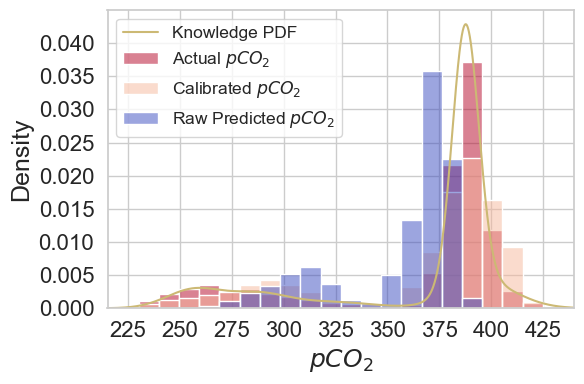

Aug 14618 218 875.9283847399727 706.8926532228862 699.8769546444482 466.01919172457747 55.69849884192324 56.558959209143865 875.8668757016756 706.6723173209484 699.663041150443 467.74639291472613 58.67526165218279 59.52508428208848 45.377892522094456 23.311892816281777 22.78033534946944 40.9638842328432 7.019606853205963 6.7383252032517476
Sep 12671 127 569.713557800851 388.9674938988152 451.00281584868037 329.5246986073984 25.295926448434354 37.445739982259695 569.885628001823 389.00638450471496 451.0643878801192 331.30861818251617 27.953454355577758 40.41154912038777 24.94062537560083 9.155932686344395 11.717068788302868 23.633657618317294 5.787946091861931 9.028316072370597
Oct 12980 89 588.6745520258344 347.87508049020255 412.72722938845556 410.73261895900237 51.822631207212375 82.0858767577947 588.7831444655307 347.9064243057852 412.7560031334762 411.83300702902403 53.587624654475896 84.40372356024217 22.07425003564006 10.364887328553648 12.790677530287079 21.746936010112137 4.968

In [24]:
# Perform calibration for each month
for month in range(12):
    raw_SE, opt_SE, stan_SE, raw_WDL, opt_WDL, stan_WDL, n_test, n_obv, raw_SE_LOO,\
    opt_SE_LOO, stan_SE_LOO, raw_WDL_LOO, opt_WDL_LOO, stan_WDL_LOO,\
    number_monthly = calibration(
        pco2_CESM002, all_provinces_CESM002, month, province, batch_size, n_components,
        is_standardize, lamb, max_step, tolerance, draw_plot=True)
    number_LOO = np.sum(number_monthly) * np.ones(7) - number_monthly
    print(month_name[month], n_test, n_obv, raw_SE / n_test, opt_SE / n_test, stan_SE / n_test,
          raw_WDL, opt_WDL, stan_WDL,
          np.mean(raw_SE_LOO / number_LOO), np.mean(opt_SE_LOO / number_LOO), np.mean(stan_SE_LOO / number_LOO),
          np.mean(raw_WDL_LOO), np.mean(opt_WDL_LOO), np.mean(stan_WDL_LOO),
          np.std(raw_SE_LOO / number_LOO), np.std(opt_SE_LOO / number_LOO), np.std(stan_SE_LOO / number_LOO),
          np.std(raw_WDL_LOO), np.std(opt_WDL_LOO), np.std(stan_WDL_LOO))

    total_raw_SE += raw_SE
    total_opt_SE += opt_SE
    total_stan_SE += stan_SE
    total_raw_WDL += raw_WDL * n_test
    total_opt_WDL += opt_WDL * n_test
    total_stan_WDL += stan_WDL * n_test
    total_n += n_test
    total_obv += n_obv

    raw_SE_LOOs[month] = raw_SE_LOO
    opt_SE_LOOs[month] = opt_SE_LOO
    stan_SE_LOOs[month] = stan_SE_LOO
    raw_WDL_LOOs[month] = raw_WDL_LOO * number_LOO
    opt_WDL_LOOs[month] = opt_WDL_LOO * number_LOO
    stan_WDL_LOOs[month] = stan_WDL_LOO * number_LOO

    number_LOOs[month] = number_LOO

In [25]:
# Print overall results
print('total number:', total_n)
print('total obv:', total_obv)
print('raw MSE:', total_raw_SE / total_n)
print('opt MSE:', total_opt_SE / total_n)
print('stan MSE:', total_stan_SE / total_n)
print('raw WDL:', total_raw_WDL / total_n)
print('opt WDL:', total_opt_WDL / total_n)
print('stan WDL:', total_stan_WDL / total_n)

raw_MSE_LOO = np.sum(raw_SE_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
opt_MSE_LOO = np.sum(opt_SE_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
stan_MSE_LOO = np.sum(stan_SE_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
raw_WDL_LOO = np.sum(raw_WDL_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
opt_WDL_LOO = np.sum(opt_WDL_LOOs, axis=0) / np.sum(number_LOOs, axis=0)
stan_WDL_LOO = np.sum(stan_WDL_LOOs, axis=0) / np.sum(number_LOOs, axis=0)

print('LOO raw MSE:', np.mean(raw_MSE_LOO))
print('LOO opt MSE:', np.mean(opt_MSE_LOO))
print('LOO stan MSE:', np.mean(stan_MSE_LOO))
print('LOO raw WDL:', np.mean(raw_WDL_LOO))
print('LOO opt WDL:', np.mean(opt_WDL_LOO))
print('LOO stan WDL:', np.mean(stan_WDL_LOO))

print('LOO raw MSE std:', np.std(raw_MSE_LOO))
print('LOO opt MSE std:', np.std(opt_MSE_LOO))
print('LOO stan MSE std:', np.std(stan_MSE_LOO))
print('LOO raw WDL std:', np.std(raw_WDL_LOO))
print('LOO opt WDL std:', np.std(opt_WDL_LOO))
print('LOO stan WDL std:', np.std(stan_WDL_LOO))

total number: 185757
total obv: 5207
raw MSE: 703.713920949942
opt MSE: 400.80352470417125
stan MSE: 421.83090269920325
raw WDL: 409.80901898310077
opt WDL: 21.846380249018917
stan WDL: 29.145839584224483
LOO raw MSE: 703.7724326060123
LOO opt MSE: 400.7847072883354
LOO stan MSE: 421.81079651774945
LOO raw WDL: 411.895100028864
LOO opt WDL: 24.396696860417585
LOO stan WDL: 31.769594972499476
LOO raw MSE std: 45.358485971058215
LOO opt MSE std: 14.188660274506532
LOO stan MSE std: 14.209275988453209
LOO raw WDL std: 41.096359805469724
LOO opt WDL std: 2.9176548701600904
LOO stan WDL std: 3.156493288487305


In [26]:
print('time:', time.time() - start)

time: 432.1741256713867
